## Import necessary library


In [ ]:
import sys
from pathlib import Path

In [ ]:
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "util" / "data_path.py").exists():
        _src = str(_p / "src")
        if _src not in sys.path:
            sys.path.insert(0, _src)
        break

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

from util.lstm_model import LSTMRegressor
from util.seq_dataset import SeqDataset
from util.config import CFG
from util.data_path import (
    cassava_long,
    corn_long,
    green_bean_long,
    soybean_long,
    LSTM_5T_for,
    LSTM_5T_err,
    weights_path,
    fig_final_lstm3,
)
from util.output_io import (
    save_forecast_csv,
    save_error_csv,
    save_summary_csv,
    load_forecast_csv,
)

## Get File path and load the csv data


In [12]:
ALL_CROPS = {
    "cassava": cassava_long,
    "corn": corn_long,
    "green_bean": green_bean_long,
    "soybean": soybean_long,
}

In [13]:
# Rolling window hyperparameters
SEQ_LEN = CFG["data"]["seq_len"]  # 12
PRED_LEN = CFG["data"]["pred_len"]  # 12
SEED = CFG["random_seed"]  # 42
EPOCHS = CFG["lstm"]["epochs"]  # 300

# Rolling window size (years of training data per window)
WINDOW_SIZE = 8
FIRST_TRAIN_START = 2004

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {device}")
print(
    f"SEQ_LEN={SEQ_LEN}, PRED_LEN={PRED_LEN}, EPOCHS={EPOCHS}, WINDOW_SIZE={WINDOW_SIZE}"
)

Device: cpu
SEQ_LEN=12, PRED_LEN=12, EPOCHS=300, WINDOW_SIZE=8


## Rolling Window Training — All 4 Crops

Trains a **3-layer LSTM** (hidden=32) using an 8-year rolling window over all 4 crops.
For each crop, 13 windows are trained (2004-2011 → 2012 through 2016-2023 → 2024).
The **final window's 12-month forecast (2024)** is saved to `LSTM_5T_for/{crop}_forecast.csv`.
Consolidated error metrics are saved to `LSTM_5T_err/`.


In [14]:
# Rolling window training and forecasting for ALL crops
print("Starting rolling window analysis for all crops...")

for crop_name, data_file in ALL_CROPS.items():
    print(f"\n{'=' * 60}")
    print(f"Crop: {crop_name.upper()}")
    print(f"{'=' * 60}")

    # Load long-format data
    long = pd.read_csv(data_file, index_col="date", parse_dates=True)[["price"]]
    assert isinstance(long.index, pd.DatetimeIndex)

    LAST_AVAILABLE_YEAR = long.index.year.max()
    num_windows = LAST_AVAILABLE_YEAR - (FIRST_TRAIN_START + WINDOW_SIZE - 1)

    print(f"Data: {long.index.year.min()} to {LAST_AVAILABLE_YEAR}")
    print(f"Rolling windows: {num_windows}")

    # Per-crop seed for reproducibility
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    all_forecasts = []
    all_actuals = []
    all_errors = []
    all_window_info = []

    for window_idx in range(num_windows):
        train_start = FIRST_TRAIN_START + window_idx
        train_end = train_start + WINDOW_SIZE - 1
        pred_year = train_end + 1

        # Prepare training data
        train = long[(long.index.year >= train_start) & (long.index.year <= train_end)][
            ["price"]
        ]
        future = long[long.index.year == pred_year][["price"]]

        if future.empty:
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train)
        series = train_scaled.reshape(-1).astype(np.float32)

        # Dataset & loader
        train_ds = SeqDataset(series, seq_len=SEQ_LEN, pred_len=PRED_LEN)
        train_loader = DataLoader(train_ds, batch_size=len(train_ds), shuffle=True)

        # 3-layer LSTM model
        model = LSTMRegressor(hidden=32, layers=3, pred_len=PRED_LEN).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

        model.train()
        for ep in range(EPOCHS):
            for seq, targ in train_loader:
                seq, targ = seq.to(device), targ.to(device)
                pred = model(seq)
                loss = criterion(pred, targ)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Predict next 12 months
        last_seq = series[-SEQ_LEN:]
        model.eval()
        with torch.no_grad():
            x = (
                torch.tensor(last_seq, dtype=torch.float32)
                .unsqueeze(0)
                .unsqueeze(-1)
                .to(device)
            )
            pred_scaled = model(x).cpu().numpy().reshape(-1)

        forecast_values = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(
            -1
        )
        months = pd.date_range(start=f"{pred_year}-01-01", periods=PRED_LEN, freq="MS")
        forecast = pd.Series(forecast_values, index=months, name="forecast_price")

        window_info = {
            "window_idx": window_idx + 1,
            "train_start": train_start,
            "train_end": train_end,
            "pred_year": pred_year,
            "forecast": forecast,
            "actual": future["price"],
            "train_size": len(train),
        }
        all_window_info.append(window_info)
        all_forecasts.append(forecast)
        all_actuals.append(future["price"])

        mae_window = mean_absolute_error(future["price"], forecast)
        all_errors.append(
            {"window": window_idx + 1, "pred_year": pred_year, "mae": mae_window}
        )

        print(
            f"  Window {window_idx + 1}/{num_windows}: {train_start}-{train_end} → {pred_year} | MAE: {mae_window:.4f}"
        )

    # ── Save the last window's forecast (2024) ──────────────────────────
    final_forecast = all_window_info[-1]["forecast"]
    save_forecast_csv(final_forecast, LSTM_5T_for, crop_name)

    # Save model weights from final window
    weight_file = weights_path / f"lstm_3layer_{crop_name}.pth"
    weights_path.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), weight_file)
    print(f"  Weights saved: {weight_file.name}")

    # ── Consolidated error metrics ───────────────────────────────────────
    combined_forecasts = pd.concat(all_forecasts)
    combined_actuals = pd.concat(all_actuals)
    cmp = pd.concat(
        [
            combined_actuals.rename("actual"),
            combined_forecasts.rename("forecast_price"),
        ],
        axis=1,
    ).dropna()

    error = cmp["actual"] - cmp["forecast_price"]
    abs_error = error.abs()
    abs_pct_error = abs_error / cmp["actual"] * 100
    mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
    mape_lstm = abs_pct_error.mean()
    accuracy = 100 - (mae_lstm / cmp["actual"].mean() * 100)

    error_df = pd.DataFrame(
        {
            "actual": cmp["actual"],
            "forecast": cmp["forecast_price"],
            "error": error,
            "abs_error": abs_error,
            "abs_pct_error": abs_pct_error,
        }
    )
    save_error_csv(error_df, LSTM_5T_err, crop_name)
    save_summary_csv(
        {
            "crop": crop_name,
            "windows": len(all_window_info),
            "mae": round(mae_lstm, 6),
            "mape": round(mape_lstm, 4),
            "accuracy": round(accuracy, 2),
        },
        LSTM_5T_err,
        crop_name,
    )
    print(
        f"  {crop_name}: MAE={mae_lstm:.4f}, MAPE={mape_lstm:.2f}%, Accuracy={accuracy:.2f}%"
    )

print(f"\n{'=' * 60}")
print("All crops processed!")

Starting rolling window analysis for all crops...

Crop: CASSAVA
Data: 2004 to 2024
Rolling windows: 13
  Window 1/13: 2004-2011 → 2012 | MAE: 1.0610
  Window 2/13: 2005-2012 → 2013 | MAE: 0.6455
  Window 3/13: 2006-2013 → 2014 | MAE: 0.0978
  Window 4/13: 2007-2014 → 2015 | MAE: 0.2652
  Window 5/13: 2008-2015 → 2016 | MAE: 0.3873
  Window 6/13: 2009-2016 → 2017 | MAE: 0.5499
  Window 7/13: 2010-2017 → 2018 | MAE: 0.9798
  Window 8/13: 2011-2018 → 2019 | MAE: 0.1984
  Window 9/13: 2012-2019 → 2020 | MAE: 0.1867
  Window 10/13: 2013-2020 → 2021 | MAE: 0.5224
  Window 11/13: 2014-2021 → 2022 | MAE: 0.8398
  Window 12/13: 2015-2022 → 2023 | MAE: 1.0860
  Window 13/13: 2016-2023 → 2024 | MAE: 0.7426
Forecast saved to: C:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T\cassava_forecast.csv
  Weights saved: lstm_3layer_cassava.pth
Error metrics saved to: C:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\erro

## Save the Forecasted Price LSTM Model


In [15]:
# Forecast CSVs and error metrics were saved inside the training loop above.
# Verify the output directory contains all 4 crop CSVs.
import os

print(f"Forecast output: {LSTM_5T_for}")
for fname in sorted(os.listdir(LSTM_5T_for)):
    if fname.endswith("_forecast.csv"):
        print(f"  {fname}")

Forecast output: C:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T
  cassava_forecast.csv
  corn_forecast.csv
  green_bean_forecast.csv
  soybean_forecast.csv


## Error Analysis (Last Crop Processed)

Consolidated error analysis using all rolling-window predictions for the **last crop** in `ALL_CROPS`.


In [16]:
# Comprehensive error analysis for rolling window results
print("\n=== ROLLING WINDOW ERROR ANALYSIS ===")

# Overall consolidated errors
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
abs_pct_error = abs_error / cmp["actual"] * 100
mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_lstm = abs_pct_error.mean()

print("\nCONSOLIDATED RESULTS ACROSS ALL WINDOWS:")
print(f"Total predictions: {len(cmp)} months")
print(f"Overall MAE: {mae_lstm:.6f}")
print(f"Overall MAPE: {mape_lstm:.4f}%")
print(f"Overall Accuracy: {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}%")

# Window-by-window detailed analysis
print("\nWINDOW-BY-WINDOW ERROR ANALYSIS:")
print(
    f"{'Window':<8} {'Year':<6} {'MAE':<12} {'MAPE':<12} {'Accuracy':<10} {'Train Period':<15}"
)
print("-" * 75)

window_maes = []
window_mapes = []
window_accuracies = []

for i, info in enumerate(all_window_info):
    actual_vals = info["actual"]
    forecast_vals = info["forecast"]

    window_error = actual_vals - forecast_vals
    window_abs_error = abs(window_error)
    window_mae = mean_absolute_error(actual_vals, forecast_vals)
    window_mape = (window_abs_error / actual_vals * 100).mean()
    window_accuracy = 100 - (window_mae / actual_vals.mean() * 100)

    window_maes.append(window_mae)
    window_mapes.append(window_mape)
    window_accuracies.append(window_accuracy)

    train_period = f"{info['train_start']}-{info['train_end']}"
    print(
        f"{info['window_idx']:<8} {info['pred_year']:<6} {window_mae:<12.6f} {window_mape:<12.4f}% {window_accuracy:<10.2f}% {train_period:<15}"
    )

# Cross-window statistics
print("\nCROSS-WINDOW STATISTICS:")
print(f"Average MAE across windows: {np.mean(window_maes):.6f}")
print(f"MAE Standard Deviation: {np.std(window_maes):.6f}")
print(
    f"Best Window MAE: {np.min(window_maes):.6f} (Window {np.argmin(window_maes) + 1})"
)
print(
    f"Worst Window MAE: {np.max(window_maes):.6f} (Window {np.argmax(window_maes) + 1})"
)
print(f"Average MAPE across windows: {np.mean(window_mapes):.4f}%")
print(f"Average Accuracy across windows: {np.mean(window_accuracies):.2f}%")

# Monthly breakdown for consolidated results
print("\nCONSOLIDATED MONTHLY ERRORS:")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,
    }
)
print(error_df.round(4))


=== ROLLING WINDOW ERROR ANALYSIS ===

CONSOLIDATED RESULTS ACROSS ALL WINDOWS:
Total predictions: 156 months
Overall MAE: 2.424649
Overall MAPE: 13.4332%
Overall Accuracy: 85.92%

WINDOW-BY-WINDOW ERROR ANALYSIS:
Window   Year   MAE          MAPE         Accuracy   Train Period   
---------------------------------------------------------------------------
1        2012   2.361948     13.3050     % 85.94     % 2004-2011      
2        2013   3.737537     20.1705     % 79.73     % 2005-2012      
3        2014   2.349542     12.7412     % 86.76     % 2006-2013      
4        2015   0.865884     5.6130      % 94.39     % 2007-2014      
5        2016   1.852565     13.0159     % 87.04     % 2008-2015      
6        2017   1.281574     8.7397      % 91.55     % 2009-2016      
7        2018   2.355810     14.1452     % 85.73     % 2010-2017      
8        2019   0.843812     5.2530      % 94.61     % 2011-2018      
9        2020   1.274584     7.4446      % 92.51     % 2012-2019      
1

## Plot The predicted data compare to an actual data


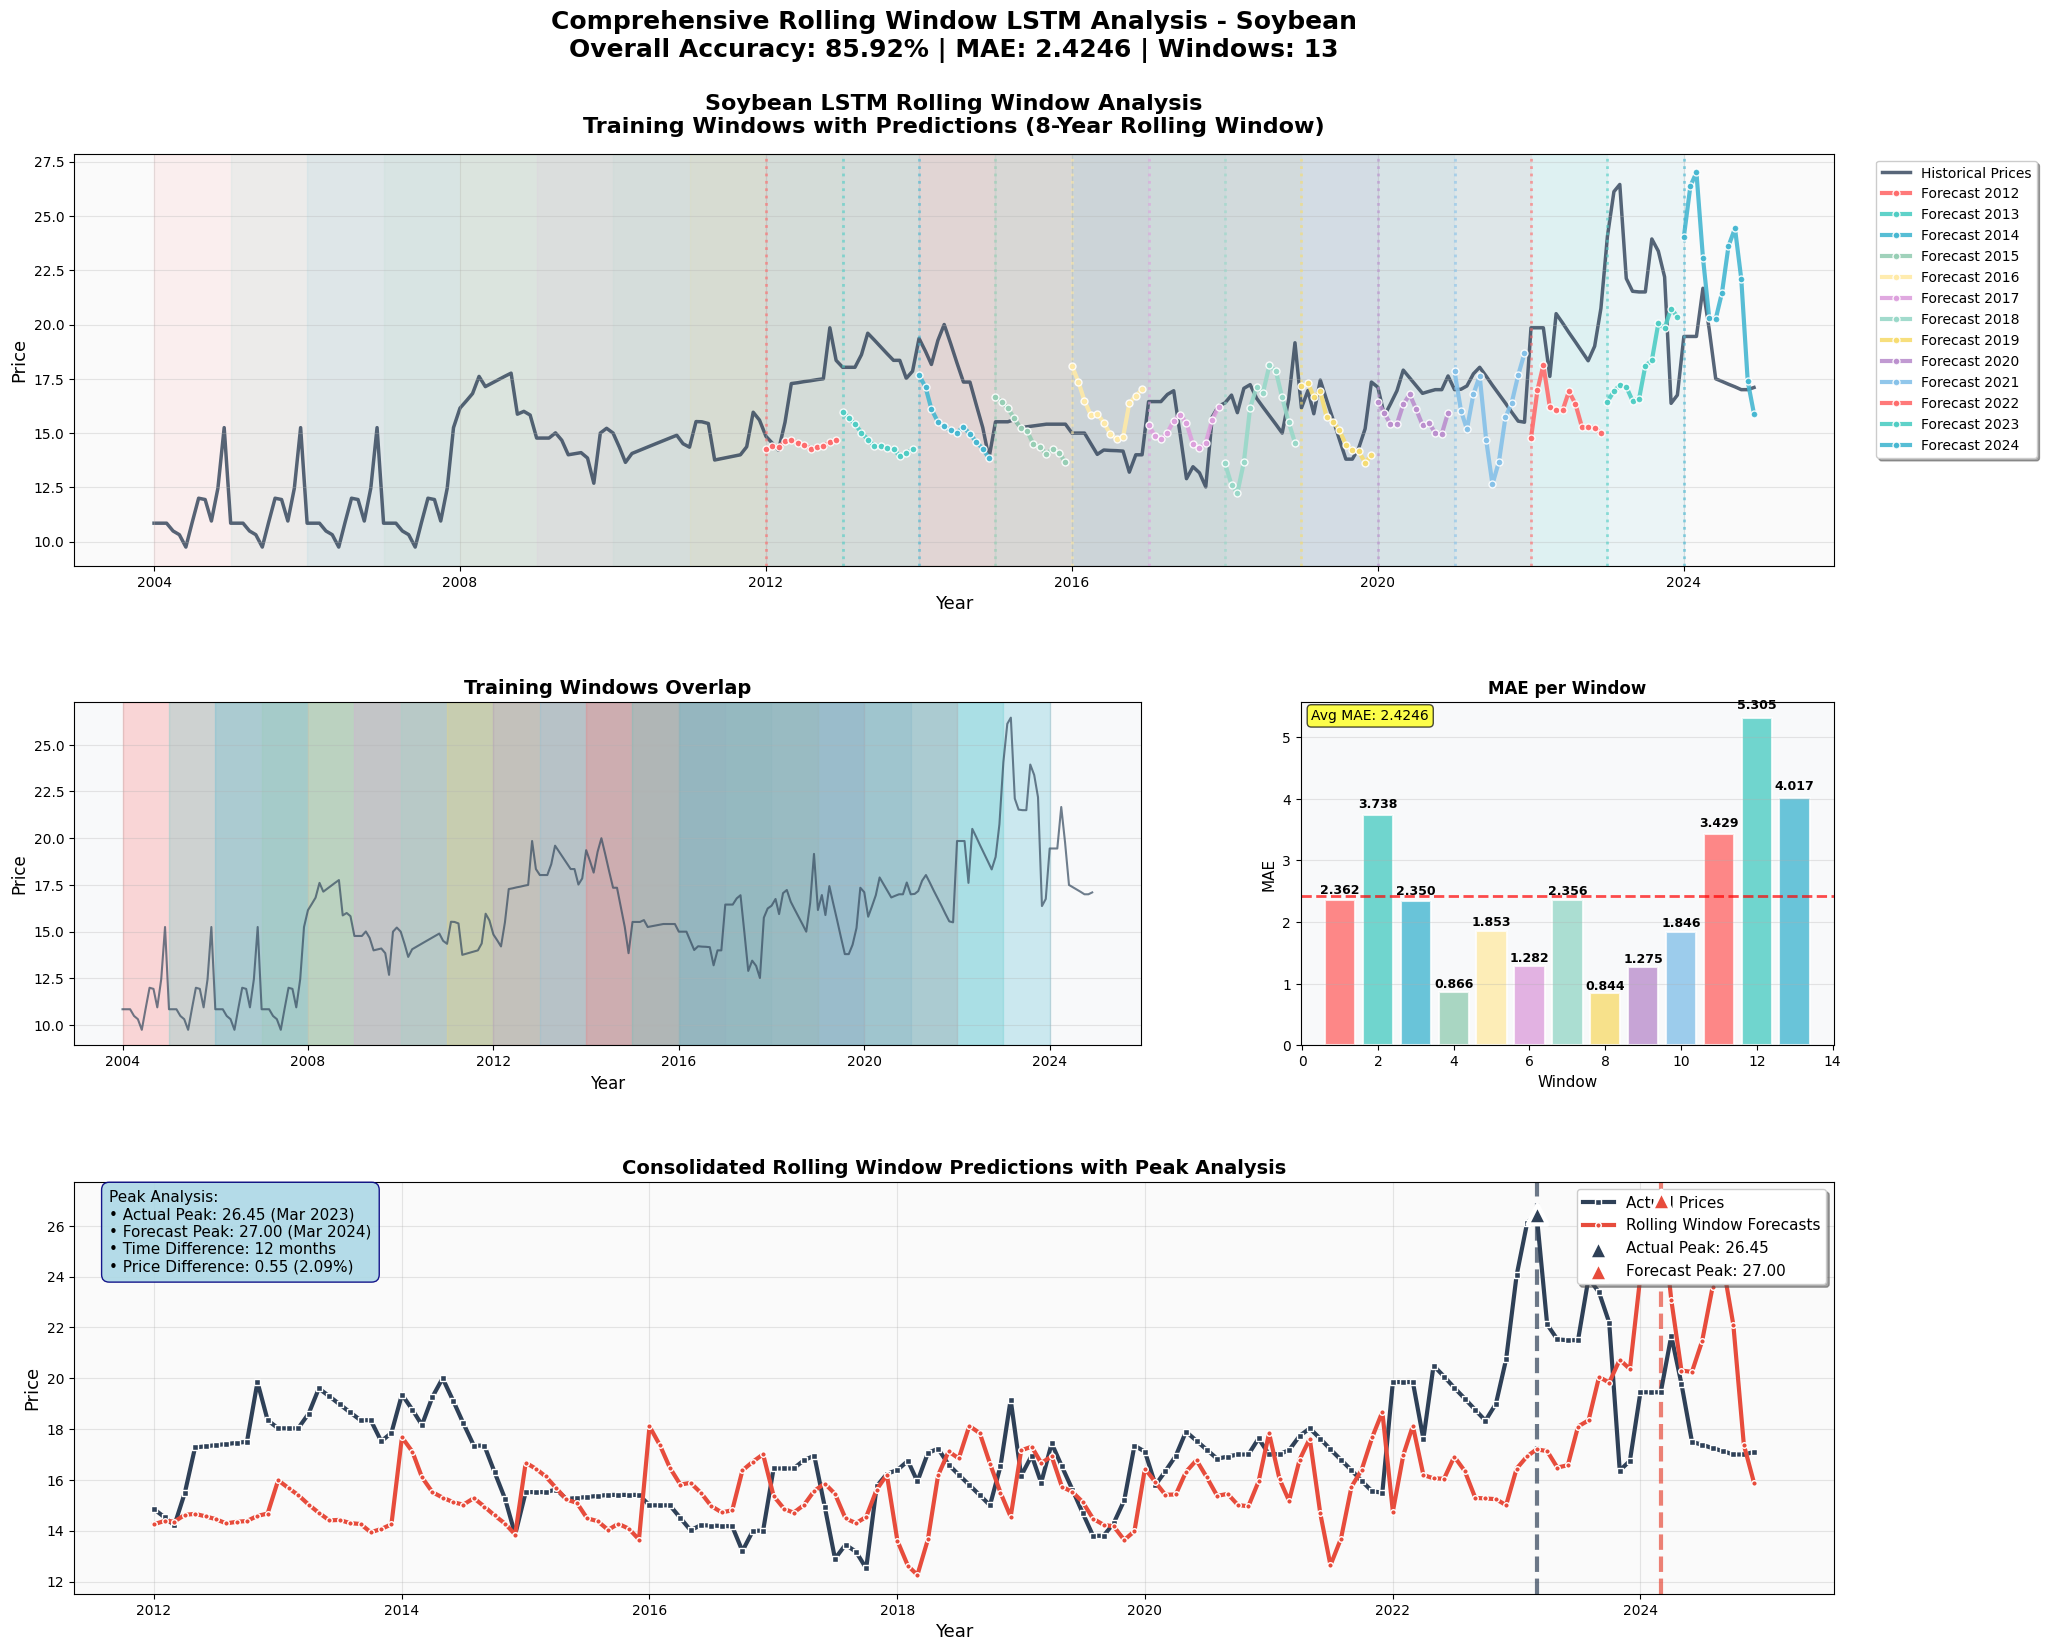

Actual Peak: 26.45 at 2023-03
Forecast Peak: 27.00 at 2024-03


In [17]:
# Rolling Window Analysis plot for the LAST processed crop (soybean)
# Variables long, cmp, all_window_info, all_errors, mae_lstm, mape_lstm
# are all set by the final iteration of the training loop above.

# Rebuild window-by-window metrics for the plot
window_maes = []
window_mapes = []
window_accuracies = []

for info in all_window_info:
    actual_vals = info["actual"]
    forecast_vals = info["forecast"]
    w_mae = mean_absolute_error(actual_vals, forecast_vals)
    w_abs = (actual_vals - forecast_vals).abs()
    w_mape = (w_abs / actual_vals * 100).mean()
    w_acc = 100 - (w_mae / actual_vals.mean() * 100)
    window_maes.append(w_mae)
    window_mapes.append(w_mape)
    window_accuracies.append(w_acc)

plt.style.use("default")
fig = plt.figure(figsize=(20, 18))

gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.2, 1, 1.2],
    width_ratios=[2, 1],
    hspace=0.35,
    wspace=0.20,
    top=0.88,
    bottom=0.08,
    left=0.06,
    right=0.94,
)

colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#96CEB4",
    "#FFEAA7",
    "#DDA0DD",
    "#98D8C8",
    "#F7DC6F",
    "#BB8FCE",
    "#85C1E9",
]

# Panel 1: Main overview
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(
    long.index,
    long["price"],
    label="Historical Prices",
    color="#2E4057",
    linewidth=2.5,
    alpha=0.8,
    zorder=1,
)

for i, info in enumerate(all_window_info):
    color = colors[i % len(colors)]
    ax_main.axvspan(
        pd.Timestamp(f"{info['train_start']}-01-01"),
        pd.Timestamp(f"{info['train_end']}-12-31"),
        alpha=0.08,
        color=color,
        zorder=0,
    )
    ax_main.plot(
        info["forecast"].index,
        info["forecast"],
        color=color,
        linewidth=3,
        alpha=0.9,
        marker="o",
        markersize=5,
        markeredgecolor="white",
        markeredgewidth=1,
        label=f"Forecast {info['pred_year']}",
        zorder=3,
    )
    ax_main.axvline(
        x=pd.Timestamp(f"{info['pred_year']}-01-01"),
        color=color,
        linestyle=":",
        alpha=0.6,
        linewidth=2,
        zorder=2,
    )

ax_main.set_title(
    f"{crop_name.capitalize()} LSTM Rolling Window Analysis\n"
    f"Training Windows with Predictions ({WINDOW_SIZE}-Year Rolling Window)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax_main.set_xlabel("Year", fontsize=13)
ax_main.set_ylabel("Price", fontsize=13)
ax_main.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=True,
)
ax_main.grid(True, alpha=0.3)
ax_main.set_facecolor("#FAFAFA")

# Panel 2: Training windows
ax_windows = fig.add_subplot(gs[1, 0])
ax_windows.plot(long.index, long["price"], color="#34495E", linewidth=1.5, alpha=0.7)
for i, info in enumerate(all_window_info):
    ax_windows.axvspan(
        pd.Timestamp(f"{info['train_start']}-01-01"),
        pd.Timestamp(f"{info['train_end']}-12-31"),
        alpha=0.25,
        color=colors[i % len(colors)],
    )
ax_windows.set_title("Training Windows Overlap", fontsize=14, fontweight="bold")
ax_windows.set_xlabel("Year", fontsize=12)
ax_windows.set_ylabel("Price", fontsize=12)
ax_windows.grid(True, alpha=0.3)
ax_windows.set_facecolor("#F8F9FA")

# Panel 3: Window MAE bars
ax_metrics = fig.add_subplot(gs[1, 1])
windows_num = [info["window_idx"] for info in all_window_info]
bars = ax_metrics.bar(
    windows_num,
    window_maes,
    color=[colors[i % len(colors)] for i in range(len(windows_num))],
    alpha=0.8,
    edgecolor="white",
    linewidth=1.5,
)
for bar, mae in zip(bars, window_maes):
    ax_metrics.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() * 1.02,
        f"{mae:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
avg_mae = np.mean(window_maes)
ax_metrics.axhline(y=avg_mae, color="red", linestyle="--", alpha=0.7, linewidth=2)
ax_metrics.text(
    0.02,
    0.98,
    f"Avg MAE: {avg_mae:.4f}",
    transform=ax_metrics.transAxes,
    bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.7),
    fontsize=10,
    va="top",
)
ax_metrics.set_title("MAE per Window", fontsize=12, fontweight="bold")
ax_metrics.set_xlabel("Window", fontsize=11)
ax_metrics.set_ylabel("MAE", fontsize=11)
ax_metrics.grid(True, alpha=0.3, axis="y")
ax_metrics.set_facecolor("#F8F9FA")

# Panel 4: Consolidated predictions with peak analysis
ax_consolidated = fig.add_subplot(gs[2, :])
ax_consolidated.plot(
    cmp.index,
    cmp["actual"],
    label="Actual Prices",
    color="#2E4057",
    linewidth=3,
    marker="s",
    markersize=4,
    markeredgecolor="white",
    markeredgewidth=1,
    zorder=4,
)
ax_consolidated.plot(
    cmp.index,
    cmp["forecast_price"],
    label="Rolling Window Forecasts",
    color="#E74C3C",
    linewidth=3,
    marker="o",
    markersize=4,
    markeredgecolor="white",
    markeredgewidth=1,
    zorder=4,
)

actual_peak_idx = cmp["actual"].idxmax()
forecast_peak_idx = cmp["forecast_price"].idxmax()
actual_peak_value = cmp["actual"].max()
forecast_peak_value = cmp["forecast_price"].max()

ax_consolidated.scatter(
    actual_peak_idx,
    actual_peak_value,
    color="#2E4057",
    s=200,
    marker="^",
    edgecolor="white",
    linewidth=3,
    zorder=6,
    label=f"Actual Peak: {actual_peak_value:.2f}",
)
ax_consolidated.scatter(
    forecast_peak_idx,
    forecast_peak_value,
    color="#E74C3C",
    s=200,
    marker="^",
    edgecolor="white",
    linewidth=3,
    zorder=6,
    label=f"Forecast Peak: {forecast_peak_value:.2f}",
)
ax_consolidated.axvline(
    x=actual_peak_idx, color="#2E4057", linestyle="--", alpha=0.7, linewidth=3
)
ax_consolidated.axvline(
    x=forecast_peak_idx, color="#E74C3C", linestyle="--", alpha=0.7, linewidth=3
)

time_diff_months = abs(
    (actual_peak_idx.year - forecast_peak_idx.year) * 12
    + (actual_peak_idx.month - forecast_peak_idx.month)
)
price_diff = abs(actual_peak_value - forecast_peak_value)
price_diff_pct = price_diff / actual_peak_value * 100

peak_text = (
    f"Peak Analysis:\n"
    f"• Actual Peak: {actual_peak_value:.2f} ({actual_peak_idx.strftime('%b %Y')})\n"
    f"• Forecast Peak: {forecast_peak_value:.2f} ({forecast_peak_idx.strftime('%b %Y')})\n"
    f"• Time Difference: {time_diff_months} months\n"
    f"• Price Difference: {price_diff:.2f} ({price_diff_pct:.2f}%)"
)
ax_consolidated.text(
    0.02,
    0.98,
    peak_text,
    transform=ax_consolidated.transAxes,
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.9, edgecolor="navy"
    ),
    fontsize=11,
    va="top",
)

ax_consolidated.set_title(
    "Consolidated Rolling Window Predictions with Peak Analysis",
    fontsize=14,
    fontweight="bold",
)
ax_consolidated.set_xlabel("Year", fontsize=13)
ax_consolidated.set_ylabel("Price", fontsize=13)
ax_consolidated.legend(
    loc="upper right", fontsize=11, frameon=True, fancybox=True, shadow=True
)
ax_consolidated.grid(True, alpha=0.3)
ax_consolidated.set_facecolor("#FAFAFA")

fig.suptitle(
    f"Comprehensive Rolling Window LSTM Analysis - {crop_name.capitalize()}\n"
    f"Overall Accuracy: {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}% | "
    f"MAE: {mae_lstm:.4f} | Windows: {len(all_window_info)}",
    fontsize=18,
    fontweight="bold",
    y=0.96,
)
plt.subplots_adjust(
    top=0.88, bottom=0.08, left=0.06, right=0.94, hspace=0.35, wspace=0.20
)
plt.show()
print(f"Actual Peak: {actual_peak_value:.2f} at {actual_peak_idx.strftime('%Y-%m')}")
print(
    f"Forecast Peak: {forecast_peak_value:.2f} at {forecast_peak_idx.strftime('%Y-%m')}"
)

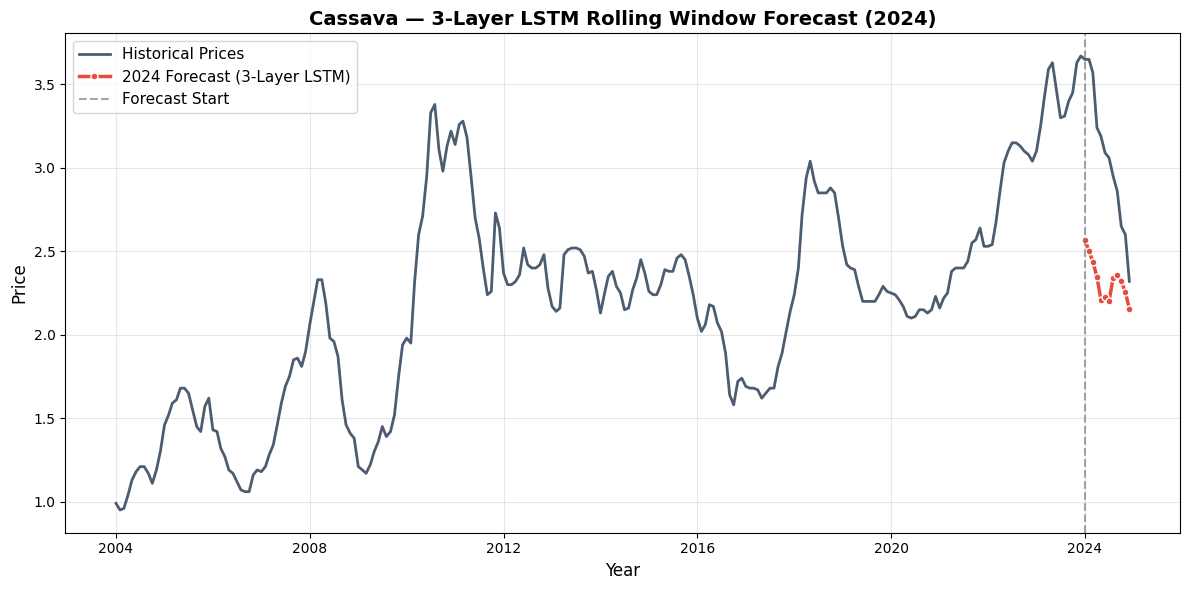

Saved: fig/final/lstm-3layer/cassava.png


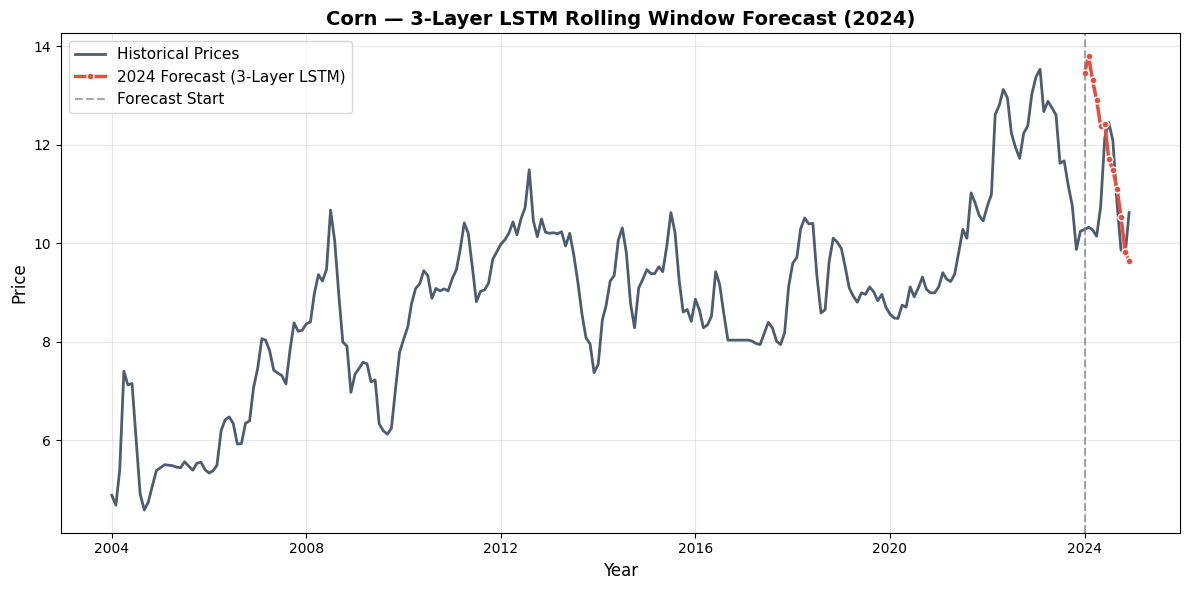

Saved: fig/final/lstm-3layer/corn.png


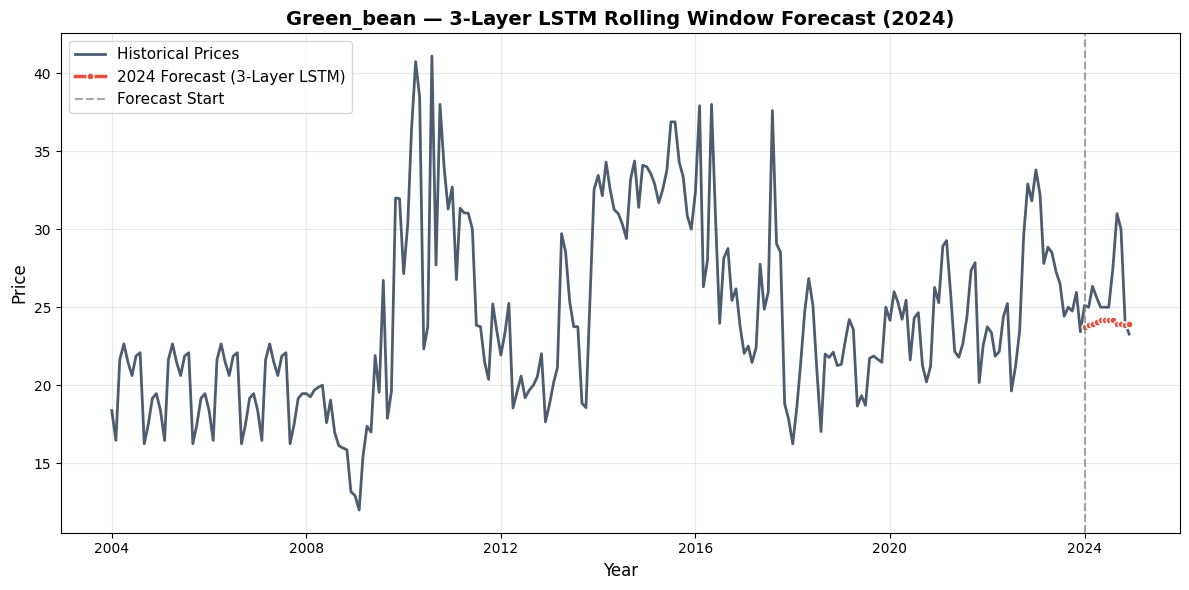

Saved: fig/final/lstm-3layer/green_bean.png


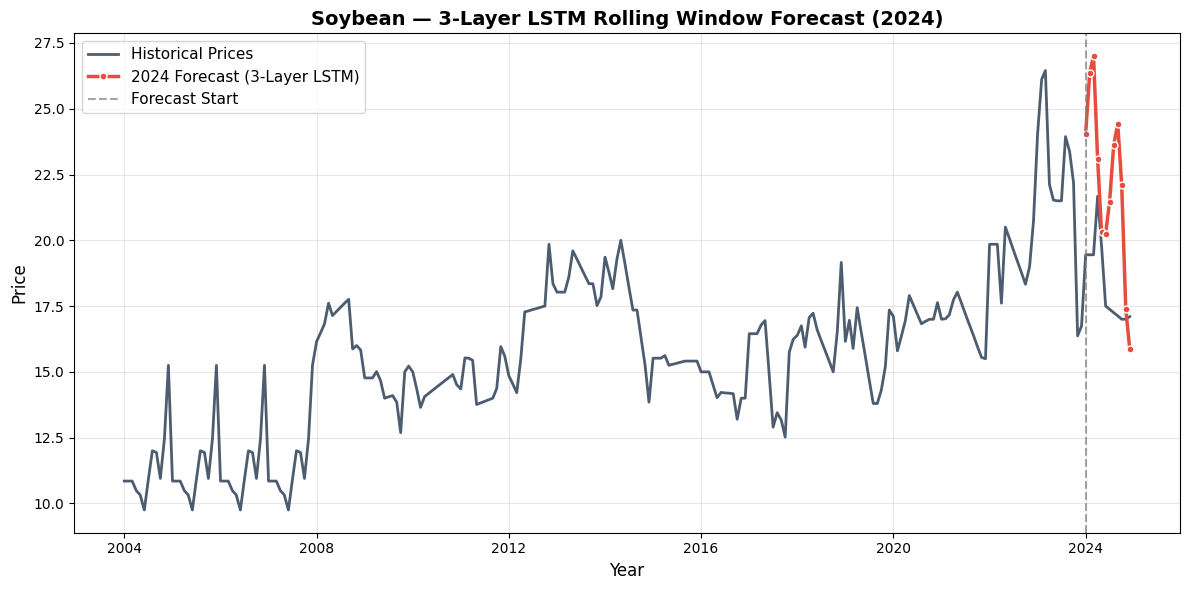

Saved: fig/final/lstm-3layer/soybean.png


In [18]:
# Save per-crop forecast comparison figures → fig/final/lstm-3layer/{crop}.png
fig_final_lstm3.mkdir(parents=True, exist_ok=True)

for crop_name_fig, data_file_fig in ALL_CROPS.items():
    long_fig = pd.read_csv(data_file_fig, index_col="date", parse_dates=True)[["price"]]
    final_fc = load_forecast_csv(LSTM_5T_for, crop_name_fig)["forecast_price"]

    fig_c, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        long_fig.index,
        long_fig["price"],
        label="Historical Prices",
        color="#2E4057",
        linewidth=2,
        alpha=0.85,
    )
    ax.plot(
        final_fc.index,
        final_fc,
        label="2024 Forecast (3-Layer LSTM)",
        color="#E74C3C",
        linewidth=2.5,
        marker="o",
        markersize=5,
        markeredgecolor="white",
        markeredgewidth=1,
    )
    ax.axvline(
        x=pd.Timestamp("2024-01-01"),
        color="gray",
        linestyle="--",
        alpha=0.7,
        label="Forecast Start",
    )
    ax.set_title(
        f"{crop_name_fig.capitalize()} — 3-Layer LSTM Rolling Window Forecast (2024)",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Price", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_final_lstm3 / f"{crop_name_fig}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: fig/final/lstm-3layer/{crop_name_fig}.png")